In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision
import torchvision.transforms as transforms

from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import numpy as np

torch: Main deep learning framework.

torchvision: Contains datasets like CIFAR-10 and useful image utilities.

transforms: Used to convert images into tensors and normalize them.

DataLoader: Loads the dataset in batches for training.

matplotlib: Used to visualize original and reconstructed images.

In [ ]:
# CIFAR-10 preprocessing

transform = transforms.Compose([
    transforms.ToTensor(),                     # Convert image to tensor
    transforms.Normalize((0.5, 0.5, 0.5),     # Normalize RGB channels
                         (0.5, 0.5, 0.5))
])

# Load training dataset
train_dataset = torchvision.datasets.CIFAR10(
    root='./data',
    train=True,
    transform=transform,
    download=True
)

# Load test dataset
test_dataset = torchvision.datasets.CIFAR10(
    root='./data',
    train=False,
    transform=transform,
    download=True
)

# Create dataloaders
train_loader = DataLoader(
    dataset=train_dataset,
    batch_size=64,
    shuffle=True
)

test_loader = DataLoader(
    dataset=test_dataset,
    batch_size=64,
    shuffle=False
)

print("Training samples:", len(train_dataset))
print("Test samples:", len(test_dataset))

100%|██████████| 170M/170M [00:04<00:00, 42.4MB/s]


Training samples: 50000
Test samples: 10000


Images are converted into tensors and normalized so that pixel values are centered around zero, which helps stabilize neural network training. DataLoader objects are created to divide the dataset into mini-batches of 64 images for efficient training and evaluation.

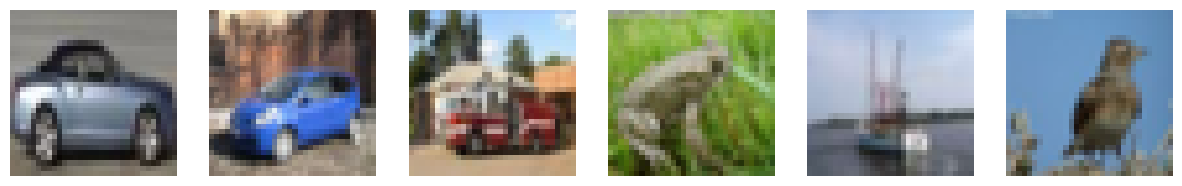

Image tensor shape: torch.Size([3, 32, 32])


In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Get a batch of images
dataiter = iter(train_loader)
images, labels = next(dataiter)

# Show first 6 images
fig, axes = plt.subplots(1, 6, figsize=(15,5))

for i in range(6):
    img = images[i] / 2 + 0.5   # unnormalize for display
    npimg = img.numpy()
    axes[i].imshow(np.transpose(npimg, (1,2,0)))
    axes[i].axis("off")

plt.show()

# Print the shape of one image
print("Image tensor shape:", images[0].shape)

input size is 32 × 32 × 3 = 3072 features.

In [ ]:
import torch.nn as nn
import torch.nn.functional as F

class SparseAutoencoder(nn.Module):

    def __init__(self, input_dim=3072, hidden_dim=1024, sparsity_lambda=1e-4, sparsity_target=0.05):
        super(SparseAutoencoder, self).__init__()

        self.sparsity_lambda = sparsity_lambda
        self.sparsity_target = sparsity_target

        # Encoder
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.Sigmoid()
        )

        # Decoder
        self.decoder = nn.Sequential(
            nn.Linear(hidden_dim, input_dim),
            nn.Tanh()
        )

    def forward(self, x):
        encoded = self.encoder(x)
        decoded = self.decoder(encoded)
        return encoded, decoded


    # KL divergence sparsity penalty
    def sparsity_penalty(self, encoded):

        rho_hat = torch.mean(encoded, dim=0)
        rho = self.sparsity_target
        epsilon = 1e-8

        rho_hat = torch.clamp(rho_hat, min=epsilon, max=1-epsilon)

        kl_div = rho * torch.log(rho / rho_hat) + (1-rho) * torch.log((1-rho) / (1-rho_hat))

        return self.sparsity_lambda * torch.sum(kl_div)


    # Total loss
    def loss_function(self, x_hat, x, encoded):

        mse_loss = F.mse_loss(x_hat, x)
        sparsity_loss = self.sparsity_penalty(encoded)

        return mse_loss + sparsity_loss

The input image is first flattened into a vector of 3072 values (because a CIFAR image is 32×32 with 3 color channels). The encoder layer compresses this large input into a smaller set of features (1024 neurons) using a sigmoid activation.

The decoder layer then tries to rebuild the original image from these features. To make the model learn meaningful features, a sparsity constraint is added so that only a few neurons activate at a time.

he training loss combines two parts: reconstruction loss (MSE), which measures how close the reconstructed image is to the original, and a sparsity penalty, which forces the hidden neurons to stay mostly inactive. This helps the model learn better feature representations of the images.

In [ ]:
# Initialize model
model = SparseAutoencoder(input_dim=3072, hidden_dim=1024)

# Optimizer
optimizer = torch.optim.Adam(model.parameters(), lr=0.0001)

# Training loop
epochs = 10

for epoch in range(epochs):

    total_loss = 0

    for images, _ in train_loader:

        # Flatten images (32x32x3 → 3072)
        images = images.view(images.size(0), -1)

        optimizer.zero_grad()

        encoded, decoded = model(images)

        loss = model.loss_function(decoded, images, encoded)

        loss.backward()

        optimizer.step()

        total_loss += loss.item()

    print(f"Epoch [{epoch+1}/{epochs}] Loss: {total_loss/len(train_loader):.4f}")

Epoch [1/10] Loss: 0.1160
Epoch [2/10] Loss: 0.0715
Epoch [3/10] Loss: 0.0601
Epoch [4/10] Loss: 0.0533
Epoch [5/10] Loss: 0.0485
Epoch [6/10] Loss: 0.0448
Epoch [7/10] Loss: 0.0418
Epoch [8/10] Loss: 0.0393
Epoch [9/10] Loss: 0.0371
Epoch [10/10] Loss: 0.0351


The Sparse Autoencoder was trained for 10 epochs on the CIFAR-10 dataset. The training loss gradually decreased from 0.1160 in the first epoch to 0.0351 in the final epoch, which indicates that the model is learning to reconstruct the input images more accurately over time.

The decreasing loss shows that the encoder is learning useful feature representations while the decoder is improving its ability to reconstruct the original images. This also suggests that the sparsity constraint and reconstruction objective are being optimized successfully during training.


In [ ]:
# Evaluate on test dataset
model.eval()

test_loss = 0

with torch.no_grad():

    for images, _ in test_loader:

        # Flatten images
        images = images.view(images.size(0), -1)

        encoded, decoded = model(images)

        loss = model.loss_function(decoded, images, encoded)

        test_loss += loss.item()

print("Average Test Loss:", test_loss / len(test_loader))

Average Test Loss: 0.035273357241111955


The trained Sparse Autoencoder was evaluated on the CIFAR-10 test dataset to measure its reconstruction performance on unseen images. The model achieved an average test loss of approximately 0.0353, which is very close to the final training loss. This indicates that the autoencoder has successfully learned meaningful feature representations and can reconstruct unseen images with similar accuracy. The small difference between training and test loss suggests that the model generalizes well and does not significantly overfit the training data.

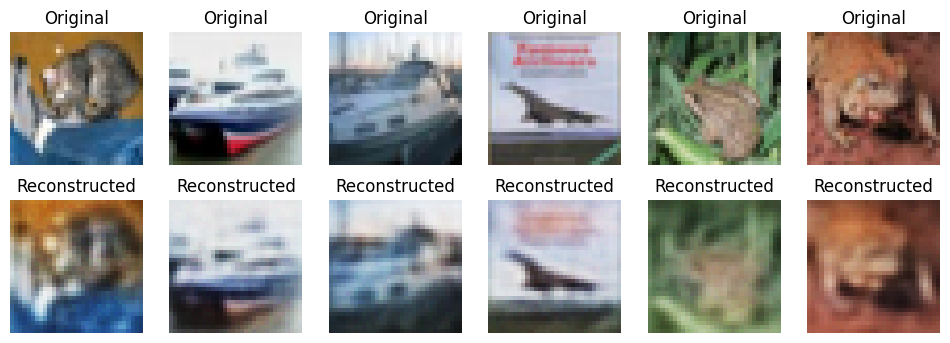

In [ ]:
# Get a batch of test images
dataiter = iter(test_loader)
images, _ = next(dataiter)

# Flatten images
flat_images = images.view(images.size(0), -1)

# Pass through autoencoder
with torch.no_grad():
    encoded, reconstructed = model(flat_images)

# Reshape reconstructed images back to 32x32x3
reconstructed = reconstructed.view(-1, 3, 32, 32)

# Plot original vs reconstructed
fig, axes = plt.subplots(2, 6, figsize=(12,4))

for i in range(6):

    # Original image
    img = images[i] / 2 + 0.5
    npimg = img.numpy()
    axes[0,i].imshow(np.transpose(npimg,(1,2,0)))
    axes[0,i].set_title("Original")
    axes[0,i].axis("off")

    # Reconstructed image
    rec = reconstructed[i] / 2 + 0.5
    npimg = rec.numpy()
    axes[1,i].imshow(np.transpose(npimg,(1,2,0)))
    axes[1,i].set_title("Reconstructed")
    axes[1,i].axis("off")

plt.show()

The reconstructed images appear slightly blurred and smoother because the autoencoder compresses the image into a limited set of features before reconstructing it. Despite the loss of fine details, the reconstructed images still preserve the main structure, colors, and object shapes. This indicates that the model has successfully learned meaningful feature representations from the dataset while maintaining sparsity in the hidden layer.

In [ ]:
sparsity_values = [1e-5, 1e-4, 1e-3]

for s in sparsity_values:

    print("\nTraining with sparsity_lambda =", s)

    model = SparseAutoencoder(input_dim=3072, hidden_dim=1024, sparsity_lambda=s)

    optimizer = torch.optim.Adam(model.parameters(), lr=0.0001)

    epochs = 5

    for epoch in range(epochs):

        total_loss = 0

        for images, _ in train_loader:

            images = images.view(images.size(0), -1)

            optimizer.zero_grad()

            encoded, decoded = model(images)

            loss = model.loss_function(decoded, images, encoded)

            loss.backward()

            optimizer.step()

            total_loss += loss.item()

        print(f"Epoch {epoch+1}, Loss: {total_loss/len(train_loader):.4f}")


Training with sparsity_lambda = 1e-05
Epoch 1, Loss: 0.0822
Epoch 2, Loss: 0.0415
Epoch 3, Loss: 0.0317
Epoch 4, Loss: 0.0266
Epoch 5, Loss: 0.0234

Training with sparsity_lambda = 0.0001
Epoch 1, Loss: 0.1164
Epoch 2, Loss: 0.0717
Epoch 3, Loss: 0.0602
Epoch 4, Loss: 0.0533
Epoch 5, Loss: 0.0485

Training with sparsity_lambda = 0.001
Epoch 1, Loss: 0.3304
Epoch 2, Loss: 0.2237
Epoch 3, Loss: 0.1922
Epoch 4, Loss: 0.1734
Epoch 5, Loss: 0.1603


As the sparsity regularization increases, the model enforces stronger sparsity in the hidden layer. This reduces the number of active neurons and encourages compact feature representations, but it also reduces reconstruction quality. Lower sparsity values produce better reconstructions, while higher sparsity values lead to higher loss and blurrier reconstructed images. This experiment demonstrates the trade-off between sparsity and reconstruction accuracy in sparse autoencoders.